<a href="https://colab.research.google.com/github/DEESHA-AFK/T076-ARTIFICIAL-INTELLIGENCE-PRACTICAL/blob/main/T076_AI_PRAC_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Demo of OpenAI/TensorFlow Tools
 Explore and experiment with OpenAI or TensorFlow tools and libraries.
 Perform a demonstration or mini-project showcasing the capabilities of the
tools.
 Discuss and present the findings and potential applications.

Saving cleaned_test.csv to cleaned_test (1).csv
Dataset Loaded Successfully!
Shape: (11399, 20)

First 5 Rows:
       ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  0x2318    COIMBRES13DEL01                  NaN                      NaN   
1  0x3474     BANGRES15DEL01                 28.0                      4.6   
2  0x9420      JAPRES09DEL03                 23.0                      4.5   
3  0x72ee      JAPRES07DEL03                 21.0                      4.8   
4  0xa759     CHENRES19DEL01                 31.0                      4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            11.003669             76.976494                   11.043669   
1            12.975377             77.696664                   13.085377   
2            26.911378             75.789034                   27.001378   
3            26.766536             75.837333                   26.856536   
4            12.986047             80.21

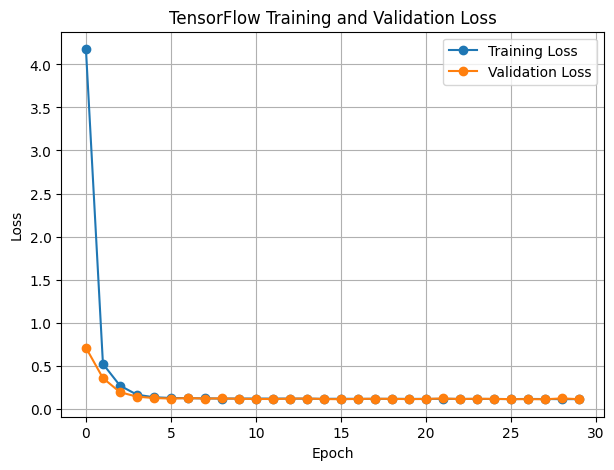

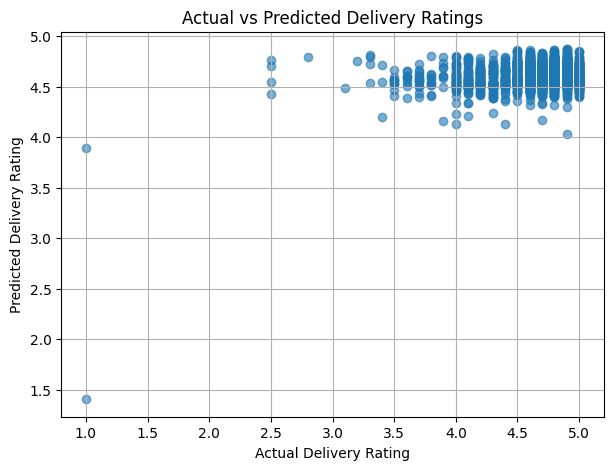

In [ ]:
# Demo of TensorFlow Tools using Business Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


# LOAD DATASET
uploaded = files.upload()

filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Dataset Loaded Successfully!")
print("Shape:", data.shape)
print("\nFirst 5 Rows:")
print(data.head())



# SELECT FEATURES
features = [
    'Delivery_person_Age',
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'Vehicle_condition',
    'multiple_deliveries'
]

target = 'Delivery_person_Ratings'

data = data[features + [target]]

# Remove missing values
data = data.dropna()

# Input and output
X = data[features].astype(float)
y = data[target].astype(float)



# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# STANDARDIZE DATA
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# CREATE TENSORFLOW MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])


# Compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# TRAIN MODEL
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# PREDICTION
y_pred = model.predict(X_test).flatten()



# EVALUATION
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE")
print("-----------------")
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))


# GRAPH 1 - TRAINING LOSS
plt.figure(figsize=(7,5))

plt.plot(
    history.history['loss'],
    label='Training Loss',
    marker='o'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()



# GRAPH 2 - ACTUAL VS PREDICTED
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Delivery Rating")
plt.ylabel("Predicted Delivery Rating")
plt.title("Actual vs Predicted Delivery Ratings")
plt.grid(True)
plt.show()